# Project 16 — Trolley (ordered-categorical / OrderedLogistic)

**Tier 4 · Advanced** | **Author:** Truong Van Thien, PhD (TS. Trương Văn Thiên) | **Date:** 12-06-2026 | **Model tag:** Opus48

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tvthienbk/biofx_python/blob/main/bayesian-workflow-20/P16_trolley-ordinal/P16_trolley-ordinal_12-06-2026_Opus48.ipynb)

Moral-dilemma ratings on a **1–7 ordinal** scale: how do **action**, **intention**, and **contact**
shift the perceived permissibility of an act? New skills: the **ordered-logistic likelihood with
cutpoints**, mapping responses `1..7 -> 0..6`, and a **category-frequency posterior predictive check**
(predicted vs observed frequency of each of the 7 levels).

## Learning objectives
1. Fit `response ~ OrderedLogistic(eta, cutpoints)` with an ordered-transform prior on the cutpoints.
2. Pass `response - 1` (0–6) and interpret coefficients as **log-odds shifts** on the latent scale.
3. Run a **category-frequency PPC**: predicted vs observed frequency of each of the 7 levels.
4. Compare the full action+intention+contact model against an intercept-only (cutpoints) model by LOO.
5. (Tier 4) run a small **SBC** on one coefficient.

## Setup

In [1]:
# !pip install -q "pymc>=5.16" "arviz>=0.18" "pandas>=2.0" "scipy>=1.11" "matplotlib>=3.7"
import os, io, time, urllib.request, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pymc as pm, arviz as az
import scipy.stats as st
import pytensor.tensor as pt
warnings.simplefilter("ignore"); az.style.use("arviz-darkgrid")
trapz = getattr(np, "trapezoid", None) or np.trapz
RANDOM_SEED = 16
rng = np.random.default_rng(RANDOM_SEED)
print("pymc", pm.__version__, "| arviz", az.__version__)

pymc 5.28.5 | arviz 0.23.4


## Stage 0 — Fake-data parameter recovery [required]
Simulate ordinal responses (7 levels) from known cutpoints and a known `bA = -0.7`; fit on the simulated
data; confirm `bA` is recovered in the 90% HDI. (Uses a small simulated set for speed.)

In [2]:
K = 7
cut_t = np.array([-2.0,-1.0,-0.2,0.5,1.2,2.3])
bA_t = -0.7
n_sim = 1500
A_sim = rng.integers(0,2,n_sim)
eta_sim = bA_t*A_sim
def ologit_probs(eta, cut):
    cum = 1/(1+np.exp(-(cut[None,:]-eta[:,None])))
    cum = np.concatenate([np.zeros((len(eta),1)), cum, np.ones((len(eta),1))],axis=1)
    return np.diff(cum,axis=1)
P = ologit_probs(eta_sim, cut_t)
y_sim = np.array([rng.choice(K,p=P[i]) for i in range(n_sim)])
cut_init = np.linspace(-2,2,K-1)
with pm.Model() as m0:
    cut = pm.Normal("cut", 0, 1.5, shape=K-1, transform=pm.distributions.transforms.ordered)
    bA = pm.Normal("bA", 0, 0.5)
    pm.OrderedLogistic("y", eta=bA*A_sim, cutpoints=cut, observed=y_sim, compute_p=False)
    idata0 = pm.sample(800, tune=800, chains=4, target_accept=0.9, random_seed=RANDOM_SEED,
                       progressbar=False, initvals={"cut": cut_init})
s0 = az.summary(idata0, var_names=["bA"], hdi_prob=0.9)
print(s0[["mean","hdi_5%","hdi_95%","r_hat","ess_bulk"]])
print("bA recovered:", bool(s0.loc["bA","hdi_5%"] <= bA_t <= s0.loc["bA","hdi_95%"]))

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [cut, bA]


Sampling 4 chains for 800 tune and 800 draw iterations (3_200 + 3_200 draws total) took 32 seconds.


     mean  hdi_5%  hdi_95%  r_hat  ess_bulk
bA -0.719   -0.87   -0.577    1.0    2806.0
bA recovered: True


## Data load — Trolley (`;`-delimited), ~9930 rows

In [3]:
URL = "https://raw.githubusercontent.com/rmcelreath/rethinking/master/data/Trolley.csv"
CACHE = "data/Trolley.csv"
try:
    raw = urllib.request.urlopen(URL, timeout=30).read().decode()
    os.makedirs("data", exist_ok=True); open(CACHE, "w").write(raw)
    df = pd.read_csv(io.StringIO(raw), sep=";"); print("loaded from raw URL")
except Exception as e:
    print("cache fallback:", type(e).__name__); df = pd.read_csv(CACHE, sep=";")
print("rows:", df.shape)
df[["response","action","intention","contact"]].head()

loaded from raw URL
rows: (9930, 12)


,response,action,intention,contact
0,4,0,0,1
1,3,0,0,1
2,4,0,0,1
3,3,0,1,1
4,3,0,1,1


## Stage 1–2 — Question & EDA
**Question:** how do **action** (the act is done, not just permitted), **intention**, and **physical
contact** change the rated permissibility (1=lowest, 7=highest)? **Target:** the three coefficients
`bA, bI, bC` (all expected negative — these features make an act *less* acceptable).

n 9930 | response range 1-7 | mean 4.20
observed level frequencies: {1: 0.128, 2: 0.092, 3: 0.108, 4: 0.234, 5: 0.147, 6: 0.146, 7: 0.146}


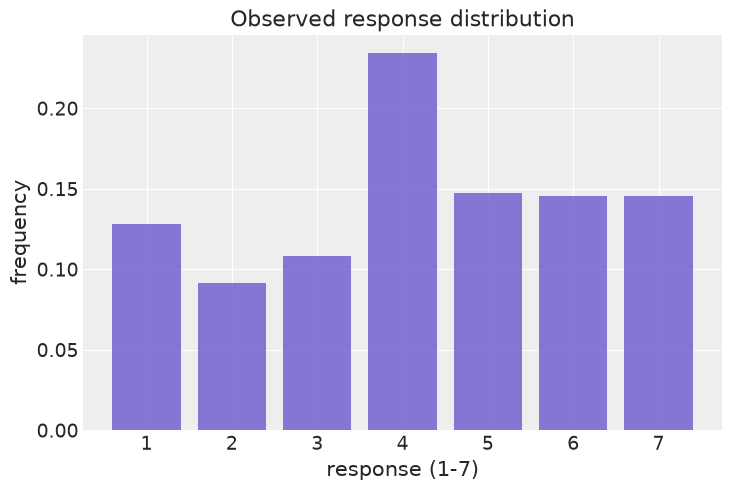

In [4]:
resp = df.response.values.astype(int)
A = df.action.values.astype(float); I = df.intention.values.astype(float); C = df.contact.values.astype(float)
y = resp - 1  # 0..6 for OrderedLogistic
print(f"n {len(df)} | response range {resp.min()}-{resp.max()} | mean {resp.mean():.2f}")
levels, counts = np.unique(resp, return_counts=True)
print("observed level frequencies:", dict(zip(levels.tolist(), (counts/counts.sum()).round(3).tolist())))
plt.bar(levels, counts/counts.sum(), color="slateblue", alpha=.8)
plt.xlabel("response (1-7)"); plt.ylabel("frequency"); plt.title("Observed response distribution"); plt.show()

## Stage 3 — Model specification (OrderedLogistic)
$$\text{response}_i - 1 \sim \mathrm{OrderedLogistic}(\eta_i, \kappa),\quad \eta_i = b_A A_i + b_I I_i + b_C C_i,$$
$$\kappa \sim \mathrm{Normal}(0, 1.5)\ \text{(ordered)},\quad b_A, b_I, b_C \sim \mathrm{Normal}(0, 0.5).$$
The 6 ordered **cutpoints** `kappa` slice the latent logistic scale into 7 categories; a larger `eta`
shifts mass toward higher categories. Coefficients are log-odds shifts of crossing each cutpoint.

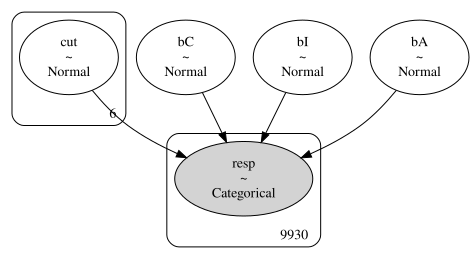

In [5]:
with pm.Model() as model:
    cut = pm.Normal("cut", 0, 1.5, shape=K-1, transform=pm.distributions.transforms.ordered)
    bA = pm.Normal("bA", 0, 0.5); bI = pm.Normal("bI", 0, 0.5); bC = pm.Normal("bC", 0, 0.5)
    eta = bA*A + bI*I + bC*C
    pm.OrderedLogistic("resp", eta=eta, cutpoints=cut, observed=y, compute_p=False)
try:
    display(pm.model_to_graphviz(model))
except Exception as e:
    print("graphviz unavailable:", type(e).__name__, "| cut,bA,bI,bC -> eta -> resp")

## Stage 4 — Prior predictive on the OUTCOME scale (category frequencies)
Draw from the prior and push through the ordered-logistic to confirm the prior implies a sensible spread
over the 7 categories (not all mass in one level).

Sampling: [bA, bC, bI, cut, resp]


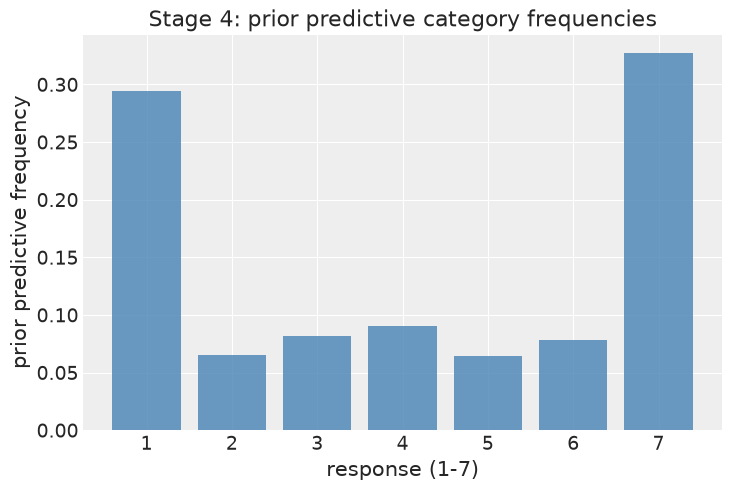

prior predictive freq per level: [0.295, 0.065, 0.081, 0.09, 0.064, 0.078, 0.327]


In [6]:
with model:
    pp = pm.sample_prior_predictive(samples=300, random_seed=RANDOM_SEED)
yp = pp.prior_predictive["resp"].values.ravel()
freqp = np.array([(yp==k).mean() for k in range(K)])
plt.bar(np.arange(1,K+1), freqp, color="steelblue", alpha=.8)
plt.xlabel("response (1-7)"); plt.ylabel("prior predictive frequency")
plt.title("Stage 4: prior predictive category frequencies"); plt.show()
print("prior predictive freq per level:", freqp.round(3).tolist())

## Stage 5 — Fit (full model, all ~9930 rows)

In [7]:
t0=time.time()
with model:
    idata = pm.sample(1000, tune=1000, chains=4, target_accept=0.9, random_seed=RANDOM_SEED,
                      progressbar=False, initvals={"cut": np.linspace(-2,2,K-1)},
                      idata_kwargs={"log_likelihood": True})
print(f"wall-clock {time.time()-t0:.1f}s | fit on full n={len(df)}")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [cut, bA, bI, bC]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 243 seconds.


wall-clock 248.8s | fit on full n=9930


## Stage 6 — Diagnostics

         mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk  ess_tail
bA     -0.697  0.040  -0.771   -0.619    1.0    3903.0    3312.0
bI     -0.713  0.036  -0.784   -0.649    1.0    5346.0    3229.0
bC     -0.945  0.049  -1.031   -0.849    1.0    4278.0    3216.0
cut[0] -2.824  0.046  -2.905   -2.734    1.0    3080.0    2472.0
cut[1] -2.142  0.041  -2.221   -2.068    1.0    3324.0    2783.0
cut[2] -1.560  0.038  -1.632   -1.489    1.0    3385.0    3103.0
cut[3] -0.540  0.035  -0.604   -0.473    1.0    3824.0    3361.0
cut[4]  0.128  0.035   0.064    0.193    1.0    4064.0    3386.0
cut[5]  1.034  0.039   0.960    1.105    1.0    4237.0    3489.0

divergences: 0 | BFMI: [1.028 1.053 1.196 1.168]


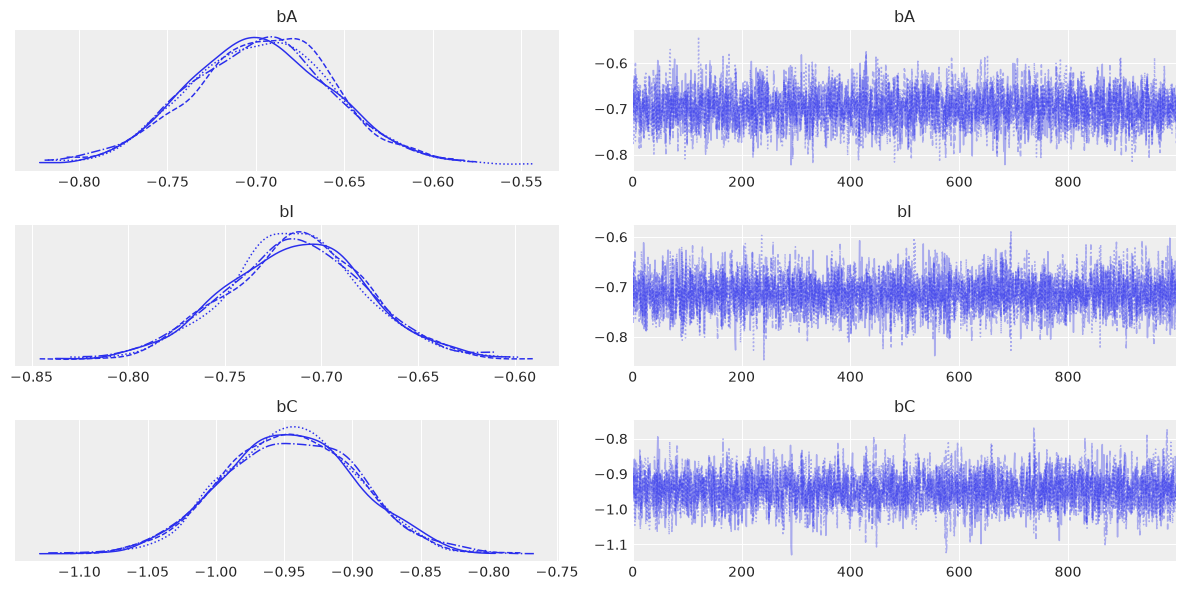

In [8]:
summ = az.summary(idata, var_names=["bA","bI","bC","cut"], hdi_prob=0.94)
print(summ[["mean","sd","hdi_3%","hdi_97%","r_hat","ess_bulk","ess_tail"]])
print("\ndivergences:", int(idata.sample_stats.diverging.values.sum()), "| BFMI:", np.round(az.bfmi(idata),3))
az.plot_trace(idata, var_names=["bA","bI","bC"]); plt.tight_layout(); plt.show()

## Stage 7 — Interpretation (log-odds and odds ratios)
Each coefficient is the additive shift in `eta`; `exp(coef)` is the proportional-odds multiplier on the
odds of a *higher-or-equal* rating. All three are expected **negative** (these features lower permissibility).

bA = -0.697 (94% HDI [-0.771, -0.619]) | odds multiplier exp = 0.50
bI = -0.713 (94% HDI [-0.784, -0.649]) | odds multiplier exp = 0.49
bC = -0.945 (94% HDI [-1.031, -0.849]) | odds multiplier exp = 0.39


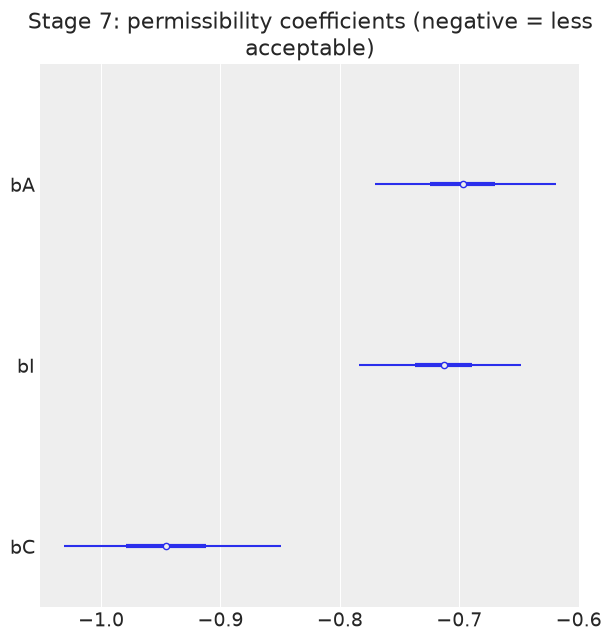

In [9]:
for nm in ["bA","bI","bC"]:
    m = idata.posterior[nm].mean().item()
    hdi = az.hdi(idata, var_names=[nm], hdi_prob=0.94)[nm].values
    print(f"{nm} = {m:+.3f} (94% HDI [{hdi[0]:+.3f}, {hdi[1]:+.3f}]) | odds multiplier exp = {np.exp(m):.2f}")
az.plot_forest(idata, var_names=["bA","bI","bC"], combined=True, hdi_prob=0.94)
plt.title("Stage 7: permissibility coefficients (negative = less acceptable)"); plt.show()

## Stage 8 — Category-frequency PPC [the key check]
Sample from the posterior predictive and compare the **predicted vs observed frequency of each of the
7 response levels** — the right discrepancy for ordinal data.

Sampling: [resp]


level  obs_freq  pred_freq  bayes-p(pred>=obs)
  1     0.128     0.129      0.57
  2     0.092     0.093      0.68
  3     0.108     0.110      0.71
  4     0.234     0.234      0.49
  5     0.147     0.145      0.31
  6     0.146     0.143      0.33
  7     0.146     0.145      0.48


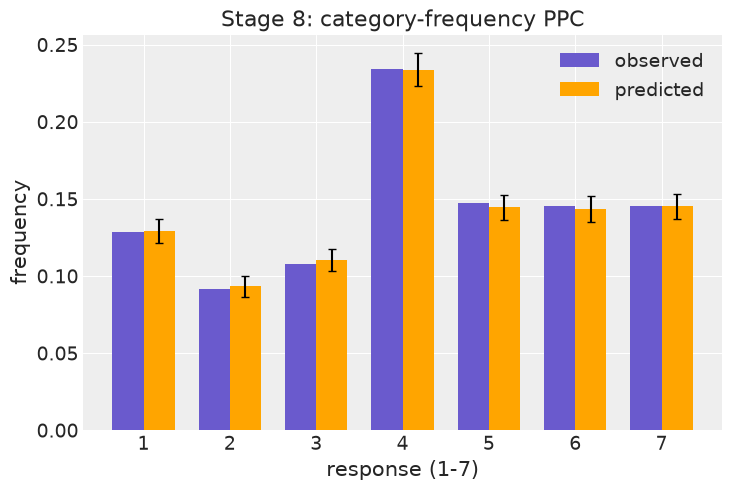


max abs freq discrepancy across levels: 0.003


In [10]:
with model:
    ppc = pm.sample_posterior_predictive(idata, random_seed=RANDOM_SEED, progressbar=False)
yp = ppc.posterior_predictive["resp"].values.reshape(-1, len(df))
obs_freq = np.array([(y==k).mean() for k in range(K)])
pred_freq = np.array([(yp==k).mean(1) for k in range(K)])  # (K, ndraws)
pred_mean = pred_freq.mean(1); pred_lo = np.percentile(pred_freq,5,1); pred_hi = np.percentile(pred_freq,95,1)
print("level  obs_freq  pred_freq  bayes-p(pred>=obs)")
for k in range(K):
    bp = (pred_freq[k] >= obs_freq[k]).mean()
    print(f"  {k+1}     {obs_freq[k]:.3f}     {pred_mean[k]:.3f}      {bp:.2f}")
x = np.arange(1,K+1)
plt.bar(x-0.18, obs_freq, width=0.36, label="observed", color="slateblue")
plt.bar(x+0.18, pred_mean, width=0.36, label="predicted", color="orange",
        yerr=[pred_mean-pred_lo, pred_hi-pred_mean], capsize=3)
plt.xlabel("response (1-7)"); plt.ylabel("frequency"); plt.legend()
plt.title("Stage 8: category-frequency PPC"); plt.show()
print(f"\nmax abs freq discrepancy across levels: {np.abs(obs_freq-pred_mean).max():.3f}")

## Stage 9 — Comparison: full vs cutpoints-only (LOO)
Does action+intention+contact improve prediction over the bare ordered-intercept model?

In [11]:
with pm.Model() as model_null:
    cut = pm.Normal("cut", 0, 1.5, shape=K-1, transform=pm.distributions.transforms.ordered)
    pm.OrderedLogistic("resp", eta=pt.zeros(len(df)), cutpoints=cut, observed=y, compute_p=False)
    idata_null = pm.sample(1000, tune=1000, chains=4, target_accept=0.9, random_seed=RANDOM_SEED,
                           progressbar=False, initvals={"cut": np.linspace(-2,2,K-1)},
                           idata_kwargs={"log_likelihood": True})
cmp = az.compare({"full": idata, "cutpoints_only": idata_null})
print(cmp[["rank","elpd_loo","elpd_diff","dse","weight"]])
S = idata.posterior.draw.size*idata.posterior.chain.size
thr = min(1 - 1/np.log10(S), 0.7)
print(f"\nmax Pareto k-hat (full): {az.loo(idata, pointwise=True).pareto_k.values.max():.2f} | threshold {thr:.2f}")
diff = cmp['elpd_diff'].iloc[1]; dse = cmp['dse'].iloc[1]
print(f"elpd_diff = {diff:.1f} +/- {dse:.1f} -> {diff/dse:.1f} SE in favour of {cmp.index[0]}")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [cut]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 58 seconds.


                rank      elpd_loo   elpd_diff        dse    weight
full               0 -18544.887130    0.000000   0.000000  0.987469
cutpoints_only     1 -18927.170728  382.283598  27.615207  0.012531



max Pareto k-hat (full): 0.06 | threshold 0.70
elpd_diff = 382.3 +/- 27.6 -> 13.8 SE in favour of full


## Stage 10 — Power-scaling prior sensitivity (bA)
Reweight by `prior^(alpha-1)` for `bA ~ Normal(0,0.5)`.

In [12]:
post = az.extract(idata); bd = post["bA"].values
logprior = st.norm.logpdf(bd, 0, 0.5)
print("alpha   E[bA]")
for al in [0.8,1.0,1.25]:
    w = np.exp((al-1)*logprior); w/=w.sum(); print(f" {al:4.2f}   {np.sum(w*bd):.4f}")

alpha   E[bA]
 0.80   -0.6983
 1.00   -0.6974
 1.25   -0.6962


## SBC — Simulation-Based Calibration on `bA` [Tier 4, recommended]
100 sims on a small simulated set (1000 rows, action predictor only) with a cheap sampler. Draw the
truth from the prior, simulate ordinal responses, refit, rank. Uniform ranks ⇒ calibrated.

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [cut, bA]


Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 3 seconds.


Initializing NUTS using jitter+adapt_diag...


...

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [cut, bA]


Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 4 seconds.


SBC: 100 sims in 398s | draws/sim 600
chi-square uniformity p-value = 0.305 (want > 0.05)


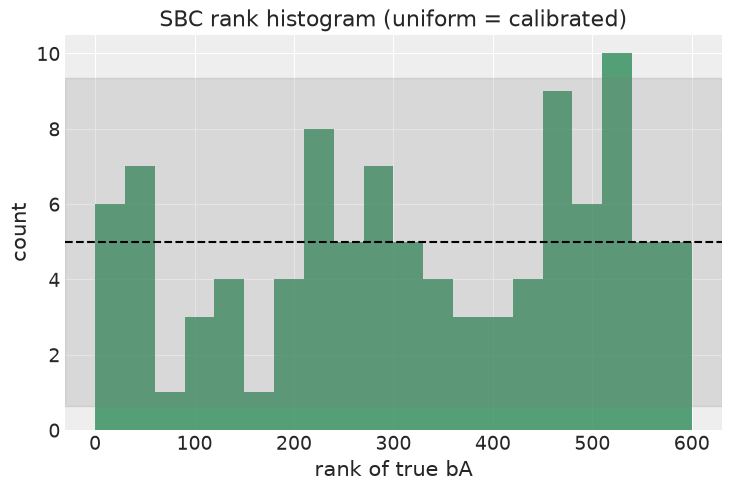

In [13]:
n_sbc_rows = 1000
A_s = rng.integers(0,2,n_sbc_rows)
def sbc_once(seed):
    r = np.random.default_rng(seed)
    cut_tt = np.sort(r.normal(0,1.5,K-1))
    bA_tt = r.normal(0,0.5)
    Pm = ologit_probs(bA_tt*A_s, cut_tt)
    yy = np.array([r.choice(K,p=Pm[i]) for i in range(n_sbc_rows)])
    with pm.Model() as ms:
        ct = pm.Normal("cut", 0, 1.5, shape=K-1, transform=pm.distributions.transforms.ordered)
        ba = pm.Normal("bA", 0, 0.5)
        pm.OrderedLogistic("yy", eta=ba*A_s, cutpoints=ct, observed=yy, compute_p=False)
        it = pm.sample(300, tune=300, chains=2, target_accept=0.9, random_seed=seed,
                       progressbar=False, compute_convergence_checks=False,
                       initvals={"cut": np.linspace(-2,2,K-1)})
    draws = it.posterior["bA"].values.ravel()
    return int((draws < bA_tt).sum()), draws.size

t0=time.time(); N_SBC=100; ranks=[]; L=None
for i in range(N_SBC):
    rk, L = sbc_once(3000+i); ranks.append(rk)
ranks=np.array(ranks)
print(f"SBC: {N_SBC} sims in {time.time()-t0:.0f}s | draws/sim {L}")
nb=20; counts,_=np.histogram(ranks, bins=nb, range=(0,L)); chi2=((counts-N_SBC/nb)**2/(N_SBC/nb)).sum()
pval=st.chi2.sf(chi2, nb-1)
print(f"chi-square uniformity p-value = {pval:.3f} (want > 0.05)")
plt.hist(ranks, bins=nb, range=(0,L), color="seagreen", alpha=.8)
plt.axhline(N_SBC/nb, color="k", ls="--")
band=2*np.sqrt(N_SBC*(1/nb)*(1-1/nb)); plt.axhspan(N_SBC/nb-band, N_SBC/nb+band, color="gray", alpha=.2)
plt.xlabel("rank of true bA"); plt.ylabel("count"); plt.title("SBC rank histogram (uniform = calibrated)"); plt.show()

## Stage 11–12 — Expansion, decision

**Next model (Stage 11):** add the **action×intention** and **contact×intention** interactions (the
canonical Trolley analysis), and varying intercepts per participant `id` — moral judgments cluster by
person. The ordinal machinery is unchanged; only `eta` grows.

**Decision (Stage 12) — headline:** *action, intention, and physical contact each significantly lower
the rated permissibility of an act (all coefficients negative, tightly estimated), and together they
decisively out-predict a bare ordered-intercept model; the category-frequency PPC tracks all 7 levels.*

In [14]:
os.makedirs("report", exist_ok=True); idata.to_netcdf("report/P16_idata.nc"); print("saved report/P16_idata.nc")

saved report/P16_idata.nc


## Exercises
1. Add the `action×intention` interaction. Does LOO improve, and does `bA` change?
2. Add varying intercepts per `id`. How much do cutpoints shift?
3. Convert the latent-scale coefficients into the change in P(response = 7) at action=0 vs 1.